## Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import shapely

# import kml reading and set supported driver
import fiona
fiona.drvsupport.supported_drivers["KML"] = "rw"

# for parsing HTML inside the Description field
from bs4 import BeautifulSoup

In [3]:
from gridsample.utils import save_shapefiles

In [4]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "01 Cleaned Khasras"

In [5]:
# Function to add suffix to duplicates
def add_suffix_to_duplicates(series):
    counts = {}
    result = []
    for item in series:
        if item in counts:
            counts[item] += 1
            result.append(f"{item}_S{counts[item]}")
        else:
            counts[item] = 0
            result.append(item)
    return result

In [6]:
# Parse description variables


def description_parser_single_row(html_content):
    # Parse the HTML content
    soup = BeautifulSoup(html_content, "html.parser")

    # Find the inner table containing the attributes
    inner_table = soup.find_all("table")[1]

    # Extract rows from the inner table
    rows = inner_table.find_all("tr")

    # Create a dictionary to store attributes and their values
    data = {}
    for row in rows:
        cols = row.find_all("td")
        if len(cols) == 2:
            key = cols[0].text.strip()
            value = cols[1].text.strip()
            data[key] = value

    return pd.DataFrame([data])


def description_parser(df, description_col_name="Description"):
    # make dataframe of variables
    data = [
        description_parser_single_row(df[description_col_name].values[i])
        for i in range(len(df))
    ]
    df_vars = pd.concat(data)
    df_vars.set_index(df.index, inplace=True)

    return df_vars

## Load raw shapes and process

### Dhar

In [7]:
# Load dhar khasras
raw_dhar_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Dhar Khasras" / "doc.kml",
    driver="KML"
)

In [8]:
# remove z-dimension
raw_dhar_gdf.geometry = raw_dhar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons and only keep the polygon
raw_dhar_gdf = raw_dhar_gdf.explode(index_parts=False)
raw_dhar_gdf = raw_dhar_gdf[raw_dhar_gdf.geometry.type == "Polygon"]

# remove useless Description column
dhar_gdf = raw_dhar_gdf.drop(columns="Description")

In [9]:
# drop large green shapes (open .KMZ on Google Earth to see)
dhar_gdf = dhar_gdf[dhar_gdf["Name"] != ""]

In [10]:
# clean up Name so we can separate the villages (string names) from the areas (numbers only)
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["Name"].str.split("/")
]
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["cleaned_name"].str.split(",")
]

In [11]:
# manual clean
dhar_gdf.loc[dhar_gdf["Name"] == "2829Z1", "cleaned_name"] = "2829"

<Axes: >

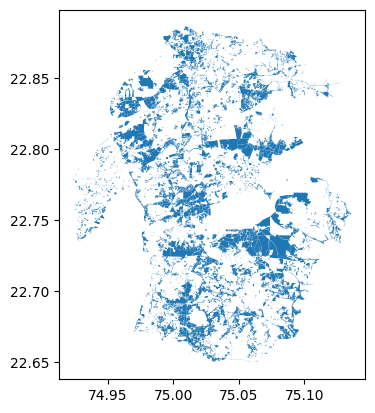

In [12]:
# ISOLATE AREA ONLY - select rows that have a number as their Name
dhar_yellow_shapes_gdf = dhar_gdf[dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_yellow_shapes_gdf.plot()

<Axes: >

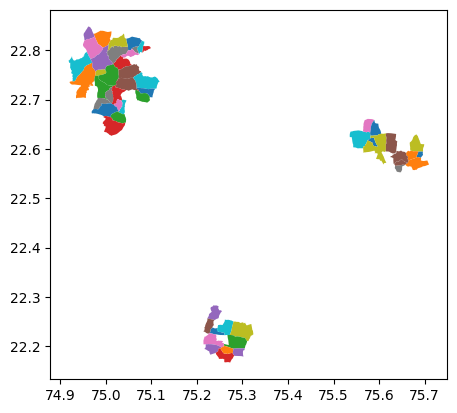

In [13]:
# ISOLATE VILLAGES ONLY - select rows that have a string as their Name
dhar_village_shapes_gdf = dhar_gdf[~dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_village_shapes_gdf = dhar_village_shapes_gdf.drop(columns="cleaned_name")
dhar_village_shapes_gdf = dhar_village_shapes_gdf.rename(
    columns={"Name": "village_name"}
)
dhar_village_shapes_gdf.plot(column="village_name")

Missing village name: 2394
Has village name: 4905


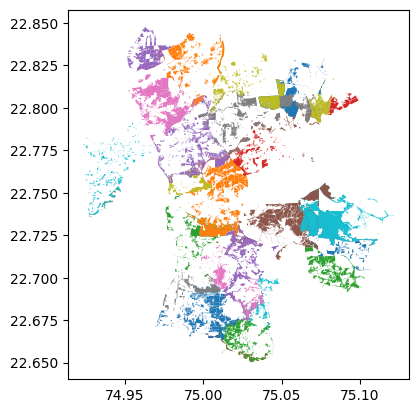

In [14]:
# add village names to areas
dhar_processed_areas_gdf = dhar_yellow_shapes_gdf.sjoin(
    dhar_village_shapes_gdf, how="left", predicate="intersects"
).drop(columns="index_right")
dhar_processed_areas_gdf.plot(column="village_name")
print("Missing village name:", dhar_processed_areas_gdf["village_name"].isnull().sum())
print("Has village name:", dhar_processed_areas_gdf["village_name"].notnull().sum())

In [15]:
# Apply the function to the khasra_id column
dhar_processed_areas_gdf["khasra_id"] = dhar_processed_areas_gdf["Name"]
dhar_processed_areas_gdf["khasra_id"] = add_suffix_to_duplicates(dhar_processed_areas_gdf["khasra_id"])

In [16]:
dhar_processed_areas_gdf.drop(columns="cleaned_name", inplace=True)

In [17]:
# save to file
save_shapefiles(
    dhar_processed_areas_gdf,
    PROCESSED_DATA_DIR,
    "dhar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Sagar

In [18]:
gdfs = []

for filename in ["sagar_khamkuwa", "sagar_mokalpur", "sagar_tekapar"]:
    gdf = gpd.read_file(
        RAW_DATA_DIR / "solar_park_shapefiles" / "Sagar Khasras" / f"{filename}.kml",
        driver="KML",
    )
    gdf["source"] = filename
    gdfs.append(gdf)

raw_sagar_gdf = pd.concat(gdfs, ignore_index=True)

<Axes: >

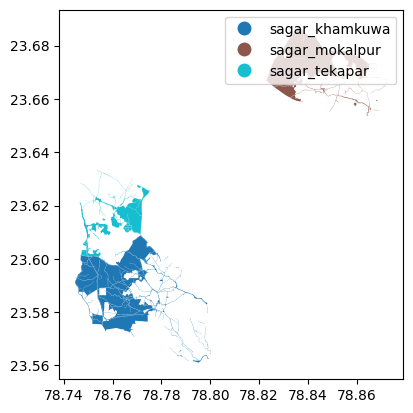

In [19]:
# remove z-dimension
raw_sagar_gdf.geometry = raw_sagar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
raw_sagar_gdf = raw_sagar_gdf.explode(column='geometry', ignore_index=True)
raw_sagar_gdf.plot(column="source", legend=True)

In [20]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(raw_sagar_gdf)
raw_sagar_gdf.drop(columns=["Name", "Description"], inplace=True)
sagar_gdf = raw_sagar_gdf.merge(df_vars, left_index=True, right_index=True)

<Axes: >

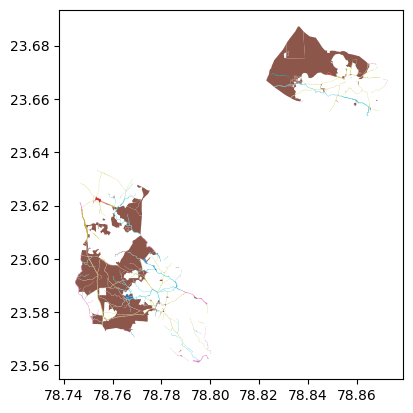

In [21]:
sagar_gdf.plot(column="PAR_TYPE")

In [22]:
sagar_gdf["village_name"] = sagar_gdf["source"].str.split("_").str[1]
sagar_gdf["source"] = sagar_gdf["source"].str.split("_").str[0]

In [23]:
# sagar_gdf["khasra_id"] = "SAGAR_" + sagar_gdf["UNQID"]
sagar_gdf["khasra_id"] = sagar_gdf["village_name"] + "_" + sagar_gdf["KID"]
sagar_gdf["khasra_id"] = add_suffix_to_duplicates(sagar_gdf["khasra_id"])

In [24]:
save_shapefiles(
    sagar_gdf,
    PROCESSED_DATA_DIR,
    "sagar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Ashok Nagar

In [25]:
gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Ashok Nagar Khasras" / "Ashok_nagar_khasras.kml",
    driver="KML",
)

In [26]:
# remove z-dimension
gdf.geometry = gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
# gdf = gdf.explode(column='geometry', ignore_index=True)

In [27]:
gdf

,Name,Description,geometry
0,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71443 24.38757, 77.71444 24..."
1,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71443 24.38757, 77.71407 24..."
2,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.72160 24.38990, 77.72142 24..."
3,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71978 24.38991, 77.71959 24..."
4,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71797 24.38994, 77.71754 24..."
...,...,...,...
342,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85647 24.70911, 77.85646 24..."
343,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85645 24.70830, 77.85648 24..."
344,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85743 24.70827, 77.85696 24..."
345,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85831 24.70821, 77.85815 24..."


<Axes: >

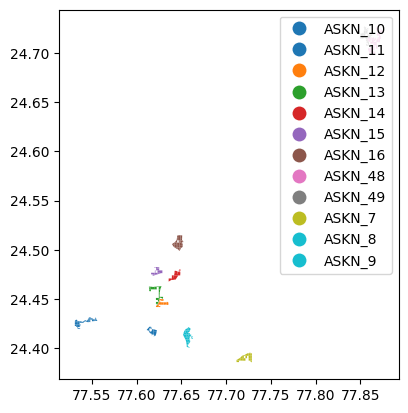

In [28]:
gdf.plot(column="Name", legend=True)

In [29]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(gdf)
gdf.drop(columns=["Name", "Description"], inplace=True)
gdf_merged = gdf.merge(df_vars, left_index=True, right_index=True)

In [30]:
gdf_merged.rename(
    columns={
        "villagee": "village_name",
        "uid": "khasra_id",
        "khasra_no": "Name",
        "Patch_Name": "parcel_id",
    },
    inplace=True,
)

In [31]:
save_shapefiles(
    gdf_merged,
    PROCESSED_DATA_DIR,
    "ashok_nagar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Shivpuri

In [32]:
raw_shivpuri_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Shivpuri Khasras" / "Shivpuri_khasra.kml",
    driver="KML",
)

In [33]:
# remove z-dimension
raw_shivpuri_gdf.geometry = raw_shivpuri_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
# gdf = gdf.explode(column='geometry', ignore_index=True)

In [34]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(raw_shivpuri_gdf)
raw_shivpuri_gdf.drop(columns=["Name", "Description"], inplace=True)
shivpuri_gdf = raw_shivpuri_gdf.merge(df_vars, left_index=True, right_index=True)

<Axes: >

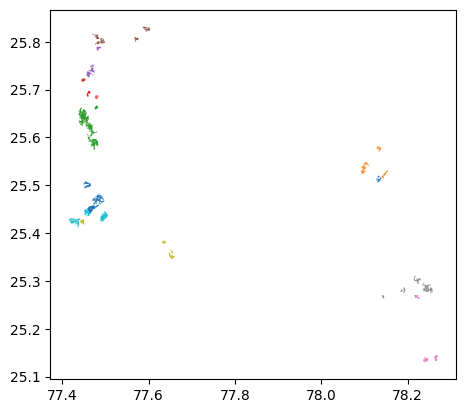

In [35]:
shivpuri_gdf.plot(column="Patch_Name")

<Axes: >

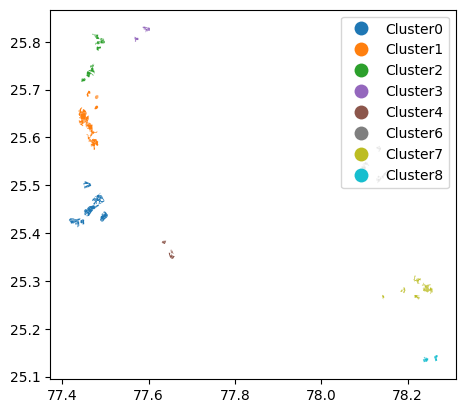

In [36]:
shivpuri_gdf.plot(column="Cluster", legend=True)

In [37]:
shivpuri_gdf

,geometry,FID,Area_ha,Patch_Name,districtc,tehsilcode,villageh,villagee,bhucode,khasra_no,...,ownername,column12in,noiyat,landtype,GIS_Area_h,teh_nm_e,ccode11,lgd_gp_cd,uid,Cluster
0,"MULTIPOLYGON (((78.23840 25.14023, 78.23810 25...",0,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2831,...,(शासकीय),,चारागाह 1.0000,शासकीय,1.033963,Pichhore,456248,151450,050603001001742831,Cluster8
1,"MULTIPOLYGON (((78.24014 25.14096, 78.23970 25...",1,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2832,...,(शासकीय),,चारागाह 3.5900,शासकीय,3.702107,Pichhore,456248,151450,050603001001742832,Cluster8
2,"MULTIPOLYGON (((78.24106 25.14042, 78.24111 25...",2,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2833,...,(शासकीय),,चारागाह 0.2300,शासकीय,0.248963,Pichhore,456248,151450,050603001001742833,Cluster8
3,"MULTIPOLYGON (((78.23943 25.13843, 78.23933 25...",3,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2836,...,(शासकीय),,चारागाह 0.9000,शासकीय,0.873786,Pichhore,456248,151450,050603001001742836,Cluster8
4,"MULTIPOLYGON (((78.23916 25.13742, 78.23912 25...",4,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2837,...,(शासकीय),,बंघीया 1.0500,शासकीय,0.038632,Pichhore,456248,151450,050603001001742837,Cluster8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,"MULTIPOLYGON (((77.47755 25.81260, 77.47613 25...",970,79.488672,SVPI_176,423,01009,ठेवला,Thewala,05090100002005,1154/2,...,(शासकीय),,0.8000पठार 0.8000 0.8000,शासकीय,0.90143,Bairrad,454991,151812,050901000020051154/2,Cluster2
971,"MULTIPOLYGON (((77.47682 25.81431, 77.47701 25...",971,79.488672,SVPI_176,423,01009,ठेवला,Thewala,05090100002005,1149/2,...,(शासकीय),,5.0000 5.0000 5.0000,शासकीय,1.768495,Bairrad,454991,151812,050901000020051149/2,Cluster2
972,"MULTIPOLYGON (((78.23841 25.13607, 78.23830 25...",972,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2855,...,(शासकीय),,पठार 0.1500,शासकीय,0.161368,Pichhore,456248,151450,050603001001742855,Cluster8
973,"MULTIPOLYGON (((78.23881 25.13629, 78.23886 25...",973,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2856,...,(शासकीय),,पठार 0.0400,शासकीय,0.055191,Pichhore,456248,151450,050603001001742856,Cluster8


In [38]:
shivpuri_gdf.columns

Index(['geometry', 'FID', 'Area_ha', 'Patch_Name', 'districtc', 'tehsilcode',
       'villageh', 'villagee', 'bhucode', 'khasra_no', 'khasra_are',
       'ownername', 'column12in', 'noiyat', 'landtype', 'GIS_Area_h',
       'teh_nm_e', 'ccode11', 'lgd_gp_cd', 'uid', 'Cluster'],
      dtype='object')

In [39]:
shivpuri_gdf.rename(
    columns={
        "villagee": "village_name",
        "uid": "khasra_id",
    },
    inplace=True,
)

In [40]:
save_shapefiles(
    shivpuri_gdf,
    PROCESSED_DATA_DIR,
    "shivpuri_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Morena

In [57]:
raw_vijaypur_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Khasras" / "vijaypur_khasras.kml",
    driver="KML",
)

# only select rows that DONT have the word Jaura or "MRA" in the name value
filtered_vijaypur_gdf = raw_vijaypur_gdf[
    ~raw_vijaypur_gdf["Name"].str.contains("Vijaypur|SEO", case=False, na=False)
]
filtered_vijaypur_gdf["source"] = "vijaypur"

# pull patch name out of the description
filtered_vijaypur_gdf["Patch Name"] = filtered_vijaypur_gdf["Description"].str.extract(r"patch_name</B> = (.+?)<BR>")

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [58]:
raw_joura_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Khasras" / "joura_khasras.kml",
    driver="KML",
)

# only select rows that DONT have the word Jaura or "MRA" in the name value
filtered_joura_gdf = raw_joura_gdf[
    ~raw_joura_gdf["Name"].str.contains("Joura|MRA", case=False, na=False)
]
filtered_joura_gdf["source"] = "joura"

# pull patch name out of the description
filtered_joura_gdf["Patch Name"] = filtered_joura_gdf["Description"].str.extract(r"patch_name</B> = (.+?)<BR>")

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [59]:
raw_solar_park_boundary_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Khasras" / "solar_park_boundary.kml",
    driver="KML",
)
raw_solar_park_boundary_gdf["source"] = "solar_park_boundary"

In [60]:
# find <td>FID</td> <td>10</td> and store the value in "Patch Name" variable
raw_solar_park_boundary_gdf["Patch Name"] = raw_solar_park_boundary_gdf["Description"].str.extract(r"<td>FID</td>\s*<td>(\d+)</td>")

In [62]:
# combine into one gdf
morena_gdf = pd.concat(
    [
        filtered_joura_gdf,
        filtered_vijaypur_gdf,
        raw_solar_park_boundary_gdf,
    ],
    ignore_index=True,
)

<Axes: >

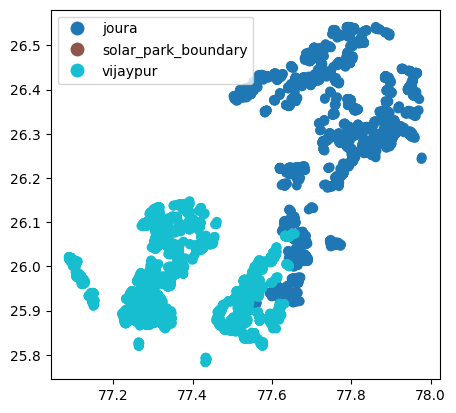

In [63]:
morena_gdf.plot(column="source", legend=True)

In [64]:
# remove z-dimension
morena_gdf.geometry = morena_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
morena_gdf_split = morena_gdf.explode(column='geometry', ignore_index=True)
# drop any single points or lines
morena_gdf_split = morena_gdf_split[morena_gdf_split.geometry.type.isin(['Polygon', 'MultiPolygon'])]

In [65]:
len(morena_gdf_split) == len(morena_gdf)

True

In [66]:
morena_gdf_split.rename(columns={"Name": "Khasra Name"}, inplace=True)

In [67]:
morena_gdf_split["Khasra ID (Unique)"] = (
    morena_gdf_split["Khasra Name"].astype(str)
    + " ("
    + morena_gdf_split["Patch Name"].astype(str)
    + ")"
)

In [69]:
save_shapefiles(
    morena_gdf_split,
    PROCESSED_DATA_DIR,
    "morena_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Barwani

In [26]:
raw_barwani_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Barwani Khasras" / "barwani_khasras.kml",
    driver="KML",
)

In [27]:
# remove z-dimension
raw_barwani_gdf.geometry = raw_barwani_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
raw_barwani_gdf_split = raw_barwani_gdf.explode(column='geometry', ignore_index=True)
# drop any single points or lines
raw_barwani_gdf_split = raw_barwani_gdf_split[raw_barwani_gdf_split.geometry.type.isin(['Polygon', 'MultiPolygon'])]

<Axes: >

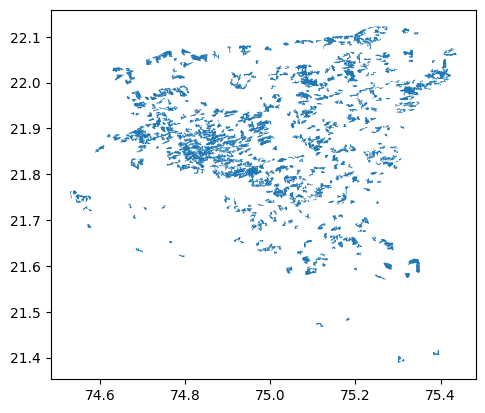

In [31]:
raw_barwani_gdf_split.plot()

In [33]:
raw_barwani_gdf_split

,Name,Description,geometry
1,"BWI20,21.382ha",Unknown Area Type,"POLYGON ((75.31239 21.39676, 75.31226 21.39676..."
3,"BWI32,66.778ha",Unknown Area Type,"POLYGON ((75.30071 21.40263, 75.30049 21.40264..."
5,"BWI48,37.171ha",Unknown Area Type,"POLYGON ((75.38583 21.41054, 75.38584 21.41073..."
7,"BWI52,33.242ha",Unknown Area Type,"POLYGON ((75.39581 21.41594, 75.39574 21.41609..."
9,"BWI99,49.073ha",Unknown Area Type,"POLYGON ((75.11652 21.47571, 75.11656 21.47571..."
...,...,...,...
32755,79/2,Unknown Area Type,"POLYGON ((74.95441 22.01890, 74.95442 22.01897..."
32757,38,Unknown Area Type,"POLYGON ((74.95441 22.01890, 74.95442 22.01897..."
32759,162,Unknown Area Type,"POLYGON ((75.08386 22.00594, 75.08385 22.00594..."
32761,120,Unknown Area Type,"POLYGON ((75.08386 22.00594, 75.08385 22.00594..."


In [46]:
# no info in Description
raw_barwani_gdf_split.drop(columns=['Description'], inplace=True)

In [65]:
# the Name column has names like BWI20,21.382ha for patches and others are khasras
# separate those who start with BWI
barwani_patches_gdf = raw_barwani_gdf_split[
    raw_barwani_gdf_split["Name"].str.startswith("BWI")
]
barwani_patches_gdf["Name"] = barwani_patches_gdf["Name"].str.split(",").str[0]
barwani_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)

# khasras
barwani_khasra_gdf = raw_barwani_gdf_split[
    ~raw_barwani_gdf_split["Name"].str.startswith("BWI")
]
barwani_khasra_gdf.rename(columns={"Name": "Khasra Name"}, inplace=True)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_46537/1137415225.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  barwani_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_46537/1137415225.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the ca

In [66]:
barwani_patches_gdf

,Patch Name,geometry
1,BWI20,"POLYGON ((75.31239 21.39676, 75.31226 21.39676..."
3,BWI32,"POLYGON ((75.30071 21.40263, 75.30049 21.40264..."
5,BWI48,"POLYGON ((75.38583 21.41054, 75.38584 21.41073..."
7,BWI52,"POLYGON ((75.39581 21.41594, 75.39574 21.41609..."
9,BWI99,"POLYGON ((75.11652 21.47571, 75.11656 21.47571..."
...,...,...
1273,BWI4548,"POLYGON ((75.32343 22.11060, 75.32340 22.11060..."
1275,BWI4550,"POLYGON ((75.25571 22.11138, 75.25571 22.11140..."
1277,BWI4553,"POLYGON ((75.24178 22.12154, 75.24160 22.12154..."
1279,BWI4556,"POLYGON ((75.25516 22.12228, 75.25468 22.12221..."


In [67]:
barwani_khasra_gdf = barwani_khasra_gdf.sjoin(barwani_patches_gdf, how="left", predicate="intersects").drop(columns=['index_right'])

In [68]:
barwani_khasra_gdf["Patch Name"].isnull().sum()

0

In [69]:
barwani_khasra_gdf

,Khasra Name,geometry,Patch Name
1283,61,"POLYGON ((75.31456 21.39287, 75.31459 21.39299...",BWI20
1285,62,"POLYGON ((75.31456 21.39287, 75.31446 21.39290...",BWI20
1287,57,"POLYGON ((75.31134 21.39444, 75.31118 21.39443...",BWI20
1289,50,"POLYGON ((75.30451 21.39008, 75.30577 21.39097...",BWI32
1291,48,"POLYGON ((75.30416 21.39163, 75.30413 21.39163...",BWI32
...,...,...,...
32755,79/2,"POLYGON ((74.95441 22.01890, 74.95442 22.01897...",BWI3935
32757,38,"POLYGON ((74.95441 22.01890, 74.95442 22.01897...",BWI3935
32759,162,"POLYGON ((75.08386 22.00594, 75.08385 22.00594...",BWI3983
32761,120,"POLYGON ((75.08386 22.00594, 75.08385 22.00594...",BWI3983


In [72]:
barwani_khasra_gdf["Khasra Name"].duplicated().sum()

12646

In [99]:
barwani_khasra_gdf["Khasra ID"] = (
    barwani_khasra_gdf["Patch Name"] + "_khasra_" + barwani_khasra_gdf["Khasra Name"]
)
# if there are duplicates, add a suffix
barwani_khasra_gdf["Khasra ID"] = barwani_khasra_gdf["Khasra ID"].astype(str)
barwani_khasra_gdf["Khasra ID"] = barwani_khasra_gdf["Khasra ID"].where(
    ~barwani_khasra_gdf["Khasra ID"].duplicated(),
    barwani_khasra_gdf["Khasra ID"]
    + "_part_"
    + barwani_khasra_gdf.groupby("Khasra ID").cumcount().astype(str),
)

In [103]:
barwani_khasra_gdf

,Khasra Name,geometry,Patch Name,Khasra ID
1283,61,"POLYGON ((75.31456 21.39287, 75.31459 21.39299...",BWI20,BWI20_khasra_61
1285,62,"POLYGON ((75.31456 21.39287, 75.31446 21.39290...",BWI20,BWI20_khasra_62
1287,57,"POLYGON ((75.31134 21.39444, 75.31118 21.39443...",BWI20,BWI20_khasra_57
1289,50,"POLYGON ((75.30451 21.39008, 75.30577 21.39097...",BWI32,BWI32_khasra_50
1291,48,"POLYGON ((75.30416 21.39163, 75.30413 21.39163...",BWI32,BWI32_khasra_48
...,...,...,...,...
32755,79/2,"POLYGON ((74.95441 22.01890, 74.95442 22.01897...",BWI3935,BWI3935_khasra_79/2_part_3
32757,38,"POLYGON ((74.95441 22.01890, 74.95442 22.01897...",BWI3935,BWI3935_khasra_38_part_3
32759,162,"POLYGON ((75.08386 22.00594, 75.08385 22.00594...",BWI3983,BWI3983_khasra_162_part_9
32761,120,"POLYGON ((75.08386 22.00594, 75.08385 22.00594...",BWI3983,BWI3983_khasra_120_part_4


In [102]:
barwani_khasra_gdf["Khasra ID"].duplicated().sum()

0

In [104]:
barwani_khasra_gdf = barwani_khasra_gdf[[
    "Khasra ID",
    "Khasra Name",
    "Patch Name",
    "geometry"
]]

In [105]:
save_shapefiles(
    barwani_khasra_gdf,
    PROCESSED_DATA_DIR,
    "barwani_cleaned_khasras",
    formats=["kml", "parquet"],
)